## **Práctica 2:  Modelo cinemático inverso de un manipulador y planteamiento de trayectoria**

**Integrantes del equipo:** 
* Espitia Castellanos Nicol 

* Minero Fujigaki Paris Alejandro

* López González Alejandro

### **1. Objetivo**

<div style="text-align: justify;">
El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa de un manipualdor serial.
</div>

<div style="text-align: justify;">

### **2. Cuestionario previo**

* **¿Qué son las transformaciones homogéneas?** 

Son matrices matemáticas que permiten representar simultáneamente la posición y orientación de un objeto o sistema de coordenadas en el espacio, respecto al sistema de referencia de una junta anterior. Esta herramienta permite realizar el planteamiento cinemático de un robot.

* **¿Qué nos permite obtener el modelo de cinemática directa de un manipulador?**

Permite obtener las ecuaciones para determinar la posición, orientación y velocidad del efector final a partir de los valores de posición y velocidad de las juntas del robot.

* **¿Qué nos permite obtener el modelo de cinemática inversa de un manipualdor?** 

El modelo de cinemática inversa de un manipulador permite obtener los valores de posición y velocidad de las juntas del robot a partir de la posición, orientación y velocidad deseadas del efector final.

* **¿De qué forma se puede interpolar la trayectoria de un efector final entre dos puntos?**

A partir de la implementación de un spline, el cual corresponde a una función polinomial que permite generar trayectorias suaves y continuas entre dos o más puntos, asegurando transiciones graduales en la posición y velocidad del efector final. </div>


### **3. Desarrollo**

#### **3.1. Planteamiento de la cinemática directa**

En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. 

![Robot a realizar practica 2](imagenes/p2_1.png)

In [ ]:
#!/usr/bin/env python3
from sympy import *
import matplotlib.pyplot as plt

In [16]:
class Robot():
  def __init__(self, l:tuple[float]=(0.3, 0.3, 0.3)):
    th1, th2, th3 = symbols("theta_1,theta_2,theta_3")

    T_0_1 = self.tr_h(gamma=pi/2,
                      alpha=th1)
    T_1_2 = self.tr_h(x = l[0],
                      alpha=th2)
    T_2_3 = self.tr_h(x = l[1],
                      alpha=th3)
    T_3_p = self.tr_h(x=l[2])

    T_0_p = T_0_1 * T_1_2 * T_2_3 * T_3_p
    T_0_p = simplify(T_0_p)
    # Vector de postura
    xi_0_p = Matrix([T_0_p[0, 3],
                     T_0_p[2, 3],
                     th1 + th2 + th3])
    # Jacobiano
    J = Matrix([[diff(xi_0_p, th1),
                 diff(xi_0_p, th2),
                 diff(xi_0_p, th3)]])
    J_inv = J.inv()

    # Velocidades del E.F. como variables
    x_dot, z_dot, beta_dot = symbols("x_dot, z_dot, beta_dot")
    # Construir polinomio lambda
    t = symbols("t")
    a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
    lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5    
    lam_dot = diff(lam, t)
    lam_dot_dot = diff(lam_dot, t)
    # Almacenar variables en el objeto
    self.th1, self.th2, self.th3 = th1, th2, th3
    self.xi_0_p = xi_0_p
    self.J_inv = J_inv
    self.x_dot, self.z_dot, self.beta_dot = symbols("x_dot, z_dot, beta_dot")
    self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5 = a_0, a_1, a_2, a_3, a_4, a_5
    self.t = t
    self.lam, self.lam_dot, self.lam_dot_dot = lam, lam_dot, lam_dot_dot

  def tr_h(self, x=0, y=0, z=0,
                 gamma=0, beta=0, alpha=0):
    t_x = Matrix([[1,          0,           0, x],
                  [0, cos(gamma), -sin(gamma), 0],
                  [0, sin(gamma),  cos(gamma), 0],
                  [0,          0,           0, 1]])
    t_y = Matrix([[ cos(beta),          0, sin(beta), 0],
                  [         0,          1,         0, y],
                  [-sin(beta),          0, cos(beta), 0],
                  [         0,          0,         0, 1]])
    t_z = Matrix([[cos(alpha), -sin(alpha), 0, 0],
                  [sin(alpha),  cos(alpha), 0, 0],
                  [         0,           0, 1, z],
                  [         0,           0, 0, 1]])
    tr = simplify(t_x * t_y * t_z)
    return tr


In [ ]:
# Instanciamos el robot 
robot = Robot()

<div style="text-align: justify;">

#### **3.2. Planteamiento de la trayectoria**

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

</div>

In [18]:
def def_tray(self, t_f:float=2, frec:float=15, 
              th_i:tuple[float]=(0.1, 0.1,0.1), 
              xi_f:tuple[float]=(0.6, 0.1, 0)):
  
  # Posición del efector final substituyendo en la postura (m, rad)
  xi_i = self.xi_0_p.subs({self.th1: th_i[0], 
                            self.th2: th_i[1], 
                            self.th3: th_i[2]})
  # Muestreo y dt
  self.dt = 1.0/frec
  self.muestras = t_f * frec + 1

  #Eq. de restricción para trayectoria
  eq1 = self.lam.subs({self.t: 0})
  eq2 = self.lam.subs({self.t: t_f}) - 1
  eq3 = self.lam_dot.subs({self.t: 0})
  eq4 = self.lam_dot.subs({self.t: t_f})
  eq5 = self.lam_dot_dot.subs({self.t: 0})
  eq6 = self.lam_dot_dot.subs({self.t: t_f})
  solutions = solve((eq1, eq2, eq3, eq4, eq5, eq6),
                (self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5))
  # Sustituyendo solución en polinimio lambda
  lam_s         = self.lam.subs(solutions)
  lam_dot_s     = self.lam_dot.subs(solutions)
  lam_dot_dot_s = self.lam_dot_dot.subs(solutions)
  
  # Ecuación de posiciones, velocidades y acc.
  xi_f = Matrix([xi_f[0], xi_f[1], xi_f[2]])
  xi_eq         = xi_i + (xi_f - xi_i) * lam_s
  xi_dot_eq     = (xi_f - xi_i) * lam_dot_s
  xi_dot_dot_eq = (xi_f - xi_i) * lam_dot_dot_s
  
  # Arreglos para almacenar muestreo
  # Tiempo
  t_m = Matrix.zeros(1, self.muestras)
  for i in range(self.muestras):
    t_m[i] = self.dt * i
  # Posición, velocidad y aceleración del E.F.
  xi_m         = Matrix.zeros(3, self.muestras)
  xi_dot_m     = Matrix.zeros(3, self.muestras)
  xi_dot_dot_m = Matrix.zeros(3, self.muestras)
  # Muestreo E.F.
  for i in range(self.muestras):
    xi_m[:, i]         = xi_eq.        subs({self.t: t_m[i]})
    xi_dot_m[:, i]     = xi_dot_eq.    subs({self.t: t_m[i]})
    xi_dot_dot_m[:, i] = xi_dot_dot_eq.subs({self.t: t_m[i]})
  print(xi_m[:, self.muestras - 1])
  # ---- Cinemática inversa
  # Velocidades de las juntas como ecuación
  th_dot_eq = self.J_inv * Matrix([self.x_dot, 
                                    self.z_dot,
                                    self.beta_dot])
  # Posición, velocidad y aceleración de las juntas
  th_m         = Matrix.zeros(3, self.muestras)
  th_dot_m     = Matrix.zeros(3, self.muestras)
  th_dot_dot_m = Matrix.zeros(3, self.muestras)
  # Agregar valor conocido
  th_m[:, 0] = Matrix([th_i[0], 
                        th_i[1], 
                        th_i[2]])
  #Muestreo de las juntas
  for i in range(self.muestras):
    # Velocidades
    th_dot_m[:, i] = th_dot_eq.subs({
      self.th1: th_m[0, i],
      self.th2: th_m[1, i],
      self.th3: th_m[2, i],
      self.x_dot:    xi_dot_m[0, i],
      self.z_dot:    xi_dot_m[1, i],
      self.beta_dot: xi_dot_m[2, i]})
    th_dot_m[:, i] = th_dot_m[:, i].evalf()
    if i < self.muestras - 1:
      # Posiciones
      th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * self.dt
    if not (i == 0):
      # Aceleración
      th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1]) / self.dt
    
  # Guardar variables en la clase 
  # Efector final
  self.xi_m         = xi_m
  self.xi_dot_m     = xi_dot_m
  self.xi_dot_dot_m = xi_dot_dot_m
  # Juntas
  self.th_m         = th_m
  self.th_dot_m     = th_dot_m
  self.th_dot_dot_m = th_dot_dot_m
  # Tiempo
  self.t_m = t_m

Robot.def_tray = def_tray

robot.def_tray() # Calcula la trayectoria a 30 muestras/seg


Matrix([[0.599999999999999], [0.100000000000000], [0]])


<div style="text-align: justify;"> 

#### **3.3 Cinemática Inversa**

A partir del modelo de la cinemática directa, obtener la expresión e la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

</div>

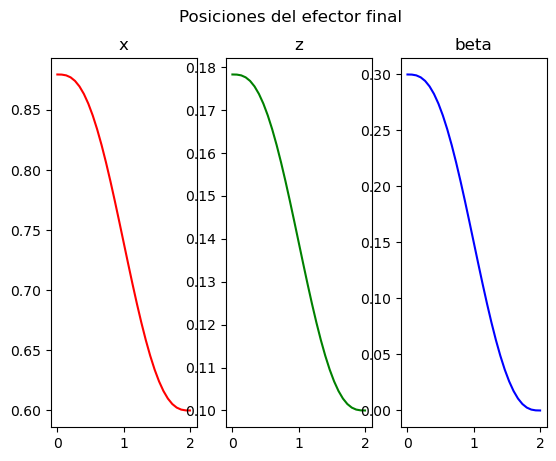

In [19]:
def imp_tray(self):
    fig, (x_g, z_g, be_g) = plt.subplots(nrows = 1, ncols = 3)
    fig.suptitle("Posiciones del efector final")
    x_g.set_title("x")
    z_g.set_title("z")
    be_g.set_title("beta")
    x_g.plot(self.t_m.T,  self.xi_m[0, :].T, color="RED")
    z_g.plot(self.t_m.T,  self.xi_m[1, :].T, color="green")
    be_g.plot(self.t_m.T, self.xi_m[2, :].T, color=(0,0,1))
    plt.show()

Robot.imp_tray = imp_tray
robot.imp_tray() # Muestra gráficas del efector final


<div style="text-align: justify;"> 

#### **3.4 Aplicación de la cinematica Inversa**

Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

</div>

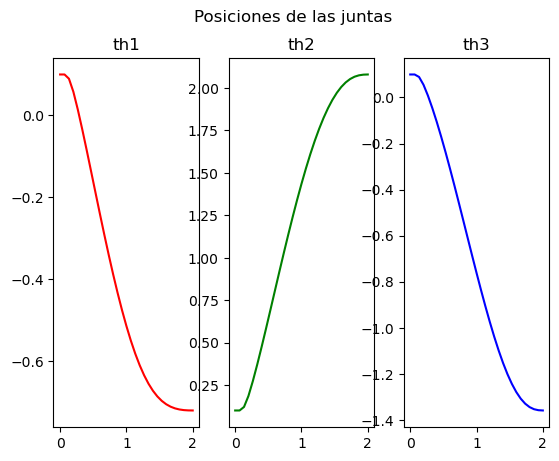

In [20]:
def imp_junt(self):
    fig, (th1_g, th2_g, th3_g) = plt.subplots(nrows = 1, ncols = 3)
    fig.suptitle("Posiciones de las juntas")
    th1_g.set_title("th1")
    th2_g.set_title("th2")
    th3_g.set_title("th3")
    th1_g.plot(self.t_m.T,  self.th_m[0, :].T, color="RED")
    th2_g.plot(self.t_m.T,  self.th_m[1, :].T, color="green")
    th3_g.plot(self.t_m.T,  self.th_m[2, :].T, color=(0,0,1))
    plt.show()

Robot.imp_junt = imp_junt
robot.imp_junt() # Muestra gráficas de las juntas mediante cinemática inversa

<div style="text-align: justify;">

### **4. Analisis de resultados**

* **¿Qué utilidad tiene el modelo de la cinématica inversa de un robot?**

A grandes rasgos nos permite conocer la posición de las juntas de un robot a partir de la posicón concocida del efector final, con el fin de conocer la posición que deben de tomar las motores para legar a dicha posición.



</div>

<div style="text-align: justify;">

### **5. Conclusiones**

Tras la realización de la práctica fue posible desarrollar el modelo de cinemática directa e inversa de un robot RRR mediante el uso de transformaciones homogéneas y el Jacobiano. Además, se implementó una trayectoria suave utilizando un polinomio de quinto grado, garantizando velocidades y aceleraciones nulas al inicio y al final del movimiento. A partir de estos modelos se obtuvieron las posiciones, velocidades y aceleraciones de las juntas necesarias para seguir la trayectoria deseada. La práctica permitió reforzar conceptos fundamentales de robótica y comprender la relación entre el movimiento del efector final y el comportamiento de las articulaciones del robot.

</div>

<div style="text-align: justify;">

### **5. Bibliografía**

[1] J. J. Craig, Introduction to Robotics: Mechanics and Control, 4th ed. Upper Saddle River, NJ, USA: Pearson, 2018.

[2] B. Siciliano, L. Sciavicco, L. Villani and G. Oriolo, Robotics: Modelling, Planning and Control. London, U.K.: Springer, 2009.

[3] P. Corke, Robotics, Vision and Control: Fundamental Algorithms in MATLAB, 2nd ed. Cham, Switzerland: Springer, 2017.

</div>